In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0, ResNet50
from tensorflow.keras.preprocessing import image

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import cv2
import os

from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data_dir = "/content/drive/MyDrive/cotton_weed"

IMG_SIZE = 224
BATCH_SIZE = 32

classes = [
    'carpetweeds',
    'crabgrass',
    'eclipta',
    'goosegrass',
    'morningglory'
]

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

dataset_dir = "/content/drive/MyDrive/cotton_weed"

IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.3
)

# 70% Training
train_data = train_datagen.flow_from_directory(
    dataset_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# 30% Validation + Test Temporary
temp_data = train_datagen.flow_from_directory(
    dataset_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 1575 images belonging to 5 classes.
Found 675 images belonging to 5 classes.


In [ ]:
import os
print(os.listdir('.'))

['.config', 'drive', 'sample_data']


In [ ]:
print("======================================")
print("DATASET SPLIT INFORMATION")
print("======================================")

print("Training Images :", train_data.samples)
print("Validation Images :", val_data.samples)
print("Testing Images :", test_data.samples)

total_images = (
    train_data.samples +
    val_data.samples +
    test_data.samples
)

print("\nTotal Images :", total_images)

print("\nClass Names :")
print(train_data.class_indices)

print("\nTotal Classes :", len(train_data.class_indices))


DATASET SPLIT INFORMATION
Training Images : 1855
Validation Images : 395
Testing Images : 335

Total Images : 2585

Class Names :
{'Carpetweeds': 0, 'Crabgrass': 1, 'Eclipta': 2, 'Goosegrass': 3, 'Morningglory': 4}

Total Classes : 5


In [58]:
resnet_base = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

resnet_base.trainable = False

print("Before Fine Tuning")
print("All layers are Frozen")

resnet_model = models.Sequential([
    resnet_base,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(5, activation='softmax')
])

resnet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nTraining with Frozen Layers...\n")

history_frozen = resnet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)

# Accuracy after freezing
frozen_acc = max(history_frozen.history['val_accuracy'])

print("\nValidation Accuracy (Frozen Layers):",
      round(frozen_acc * 100, 2), "%")

Before Fine Tuning
All layers are Frozen

Training with Frozen Layers...

Epoch 1/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 61s 840ms/step - accuracy: 0.2140 - loss: 1.6590 - val_accuracy: 0.2000 - val_loss: 1.6160
Epoch 2/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 38s 661ms/step - accuracy: 0.2189 - loss: 1.6090 - val_accuracy: 0.2405 - val_loss: 1.6044
Epoch 3/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 38s 653ms/step - accuracy: 0.2205 - loss: 1.6022 - val_accuracy: 0.2380 - val_loss: 1.5993
Epoch 4/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 37s 634ms/step - accuracy: 0.2420 - loss: 1.6028 - val_accuracy: 0.2380 - val_loss: 1.5984
Epoch 5/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 39s 670ms/step - accuracy: 0.2194 - loss: 1.6028 - val_accuracy: 0.2025 - val_loss: 1.6022
Epoch 6/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 37s 636ms/step - accuracy: 0.2431 - loss: 1.5991 - val_accuracy: 0.2734 - val_loss: 1.5942
Epoch 7/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 38s 646ms/step - accuracy: 0.2108 - loss: 1.6006 - val_accuracy: 0.2127 - val_loss: 1.5967
Epoch 8/15
58/58 ━━━━━━

In [59]:
from tensorflow.keras.optimizers import Adam

resnet_base.trainable = True

for layer in resnet_base.layers[:-30]:
    layer.trainable = False

print("\nAfter Fine Tuning")
print("Top layers are Unfrozen")


for layer in resnet_base.layers[-10:]:
    print(layer.name, ":", layer.trainable)

resnet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nTraining After Unfreezing Layers...\n")

history_unfrozen = resnet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=30
)

unfrozen_acc = max(history_unfrozen.history['val_accuracy'])

print("\nValidation Accuracy (After Unfreezing):",
      round(unfrozen_acc * 100, 2), "%")


After Fine Tuning
Top layers are Unfrozen
conv5_block3_1_conv : True
conv5_block3_1_bn : True
conv5_block3_1_relu : True
conv5_block3_2_conv : True
conv5_block3_2_bn : True
conv5_block3_2_relu : True
conv5_block3_3_conv : True
conv5_block3_3_bn : True
conv5_block3_add : True
conv5_block3_out : True

Training After Unfreezing Layers...

Epoch 1/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 76s 964ms/step - accuracy: 0.2642 - loss: 1.6435 - val_accuracy: 0.2380 - val_loss: 1.6122
Epoch 2/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 42s 716ms/step - accuracy: 0.3439 - loss: 1.4847 - val_accuracy: 0.2709 - val_loss: 1.5847
Epoch 3/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 41s 701ms/step - accuracy: 0.4032 - loss: 1.3845 - val_accuracy: 0.2228 - val_loss: 1.8901
Epoch 4/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 43s 744ms/step - accuracy: 0.4631 - loss: 1.3044 - val_accuracy: 0.4304 - val_loss: 1.3620
Epoch 5/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 38s 664ms/step - accuracy: 0.4690 - loss: 1.2801 - val_accuracy: 0.4405 - val_loss: 1.5064
Epoch 6/30
58/58

In [61]:
print("\n======================================")
print("FREEZING vs UNFREEZING ACCURACY")
print("======================================")

print("Accuracy with Frozen Layers      :",
      round(frozen_acc * 100, 2), "%")

print("Accuracy after Unfreezing Layers :",
      round(unfrozen_acc * 100, 2), "%")

print("Improvement in Accuracy          :",
      round((unfrozen_acc - frozen_acc) * 100, 2), "%")


FREEZING vs UNFREEZING ACCURACY
Accuracy with Frozen Layers      : 27.34 %
Accuracy after Unfreezing Layers : 54.18 %
Improvement in Accuracy          : 26.84 %


In [63]:

from tensorflow.keras.applications import DenseNet121
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

dense_base = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
dense_base.trainable = False

print("Before Fine Tuning")
print("All layers are Frozen")

dense_model = models.Sequential([
    dense_base,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(5, activation='softmax')
])

dense_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nTraining with Frozen Layers...\n")

history_frozen = dense_model.fit(
    train_data,
    validation_data=val_data,
    epochs=30
)
frozen_acc = max(history_frozen.history['val_accuracy'])

print("\nValidation Accuracy (Frozen Layers):",
      round(frozen_acc * 100, 2), "%")


Before Fine Tuning
All layers are Frozen

Training with Frozen Layers...

Epoch 1/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.5396 - loss: 1.1376 - val_accuracy: 0.7443 - val_loss: 0.7146
Epoch 2/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 39s 663ms/step - accuracy: 0.7639 - loss: 0.6352 - val_accuracy: 0.8177 - val_loss: 0.4908
Epoch 3/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 39s 682ms/step - accuracy: 0.8194 - loss: 0.4856 - val_accuracy: 0.8608 - val_loss: 0.3897
Epoch 4/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 39s 682ms/step - accuracy: 0.8598 - loss: 0.4092 - val_accuracy: 0.8734 - val_loss: 0.4042
Epoch 5/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 38s 653ms/step - accuracy: 0.8712 - loss: 0.3586 - val_accuracy: 0.8911 - val_loss: 0.3236
Epoch 6/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 39s 683ms/step - accuracy: 0.8836 - loss: 0.3326 - val_accuracy: 0.8582 - val_loss: 0.3547
Epoch 7/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 38s 664ms/step - accuracy: 0.8927 - loss: 0.3019 - val_accuracy: 0.9038 - val_loss: 0.2614
Epoch 8/30
58/58 ━━━━━━━━

In [66]:
dense_base.trainable = True

for layer in dense_base.layers[:-30]:
    layer.trainable = False

print("\nAfter Fine Tuning")
print("Top layers are Unfrozen")

for layer in dense_base.layers[-10:]:
    print(layer.name, ":", layer.trainable)

dense_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nTraining After Unfreezing Layers...\n")

history_unfrozen = dense_model.fit(
    train_data,
    validation_data=val_data,
    epochs=30

)

unfrozen_acc = max(history_unfrozen.history['val_accuracy'])

print("\nValidation Accuracy (After Unfreezing):",
      round(unfrozen_acc * 100, 2), "%")


After Fine Tuning
Top layers are Unfrozen
conv5_block15_concat : True
conv5_block16_0_bn : True
conv5_block16_0_relu : True
conv5_block16_1_conv : True
conv5_block16_1_bn : True
conv5_block16_1_relu : True
conv5_block16_2_conv : True
conv5_block16_concat : True
bn : True
relu : True

Training After Unfreezing Layers...

Epoch 1/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.9693 - loss: 0.0929 - val_accuracy: 0.9367 - val_loss: 0.1906
Epoch 2/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 40s 685ms/step - accuracy: 0.9714 - loss: 0.0795 - val_accuracy: 0.9291 - val_loss: 0.2298
Epoch 3/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 40s 699ms/step - accuracy: 0.9795 - loss: 0.0718 - val_accuracy: 0.9443 - val_loss: 0.2198
Epoch 4/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 42s 730ms/step - accuracy: 0.9774 - loss: 0.0666 - val_accuracy: 0.9671 - val_loss: 0.1016
Epoch 5/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 40s 691ms/step - accuracy: 0.9757 - loss: 0.0722 - val_accuracy: 0.9468 - val_loss: 0.1501
Epoch 6/30
58/58 ━━━━━━━━━━━━━━━━━

In [67]:

print("\n======================================")
print("FREEZING vs UNFREEZING ACCURACY")
print("======================================")

print("Accuracy with Frozen Layers      :",
      round(frozen_acc * 100, 2), "%")

print("Accuracy after Unfreezing Layers :",
      round(unfrozen_acc * 100, 2), "%")

print("Improvement in Accuracy          :",
      round((unfrozen_acc - frozen_acc) * 100, 2), "%")


FREEZING vs UNFREEZING ACCURACY
Accuracy with Frozen Layers      : 93.67 %
Accuracy after Unfreezing Layers : 97.72 %
Improvement in Accuracy          : 4.05 %


In [69]:
from tensorflow.keras.applications import Xception
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

xception_base = Xception(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

xception_base.trainable = False

print("Before Fine Tuning")
print("All layers are Frozen")

xception_model = models.Sequential([
    xception_base,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(5, activation='softmax')
])

xception_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nTraining with Frozen Layers...\n")

history_frozen = xception_model.fit(
    train_data,
    validation_data=val_data,
    epochs=30
)

frozen_acc = max(history_frozen.history['val_accuracy'])

print("\nValidation Accuracy (Frozen Layers):",
      round(frozen_acc * 100, 2), "%")

Before Fine Tuning
All layers are Frozen

Training with Frozen Layers...

Epoch 1/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.6566 - loss: 0.8824 - val_accuracy: 0.8000 - val_loss: 0.5723
Epoch 2/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 41s 708ms/step - accuracy: 0.8081 - loss: 0.5172 - val_accuracy: 0.8354 - val_loss: 0.4726
Epoch 3/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 41s 707ms/step - accuracy: 0.8243 - loss: 0.4550 - val_accuracy: 0.8354 - val_loss: 0.4219
Epoch 4/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 39s 671ms/step - accuracy: 0.8615 - loss: 0.3939 - val_accuracy: 0.8506 - val_loss: 0.3846
Epoch 5/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 40s 698ms/step - accuracy: 0.8615 - loss: 0.3554 - val_accuracy: 0.8203 - val_loss: 0.4545
Epoch 6/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 40s 700ms/step - accuracy: 0.8744 - loss: 0.3460 - val_accuracy: 0.8608 - val_loss: 0.3709
Epoch 7/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 41s 702ms/step - accuracy: 0.8873 - loss: 0.3131 - val_accuracy: 0.8557 - val_loss: 0.3519
Epoch 8/30
58/58 ━━━━━━━━━

In [70]:
xception_base.trainable = True

for layer in xception_base.layers[:-30]:
    layer.trainable = False

print("\nAfter Fine Tuning")
print("Top layers are Unfrozen")

for layer in xception_base.layers[-10:]:
    print(layer.name, ":", layer.trainable)

xception_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nTraining After Unfreezing Layers...\n")

history_unfrozen = xception_model.fit(
    train_data,
    validation_data=val_data,
    epochs=30
)

unfrozen_acc = max(history_unfrozen.history['val_accuracy'])

print("\nValidation Accuracy (After Unfreezing):",
      round(unfrozen_acc * 100, 2), "%")


After Fine Tuning
Top layers are Unfrozen
conv2d_11 : True
block13_pool : True
batch_normalization_11 : True
add_35 : True
block14_sepconv1 : True
block14_sepconv1_bn : True
block14_sepconv1_act : True
block14_sepconv2 : True
block14_sepconv2_bn : True
block14_sepconv2_act : True

Training After Unfreezing Layers...

Epoch 1/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.8577 - loss: 0.3985 - val_accuracy: 0.8937 - val_loss: 0.4166
Epoch 2/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 42s 721ms/step - accuracy: 0.9472 - loss: 0.1560 - val_accuracy: 0.8962 - val_loss: 0.4967
Epoch 3/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 42s 726ms/step - accuracy: 0.9612 - loss: 0.1346 - val_accuracy: 0.9038 - val_loss: 0.3687
Epoch 4/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 43s 737ms/step - accuracy: 0.9655 - loss: 0.1035 - val_accuracy: 0.9443 - val_loss: 0.1748
Epoch 5/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 40s 693ms/step - accuracy: 0.9709 - loss: 0.0854 - val_accuracy: 0.9316 - val_loss: 0.2635
Epoch 6/30
58/58 ━━━━━━━━━━━━━━━━━━━━

In [71]:
print("\n======================================")
print("FREEZING vs UNFREEZING ACCURACY")
print("======================================")

print("Accuracy with Frozen Layers      :",
      round(frozen_acc * 100, 2), "%")

print("Accuracy after Unfreezing Layers :",
      round(unfrozen_acc * 100, 2), "%")

print("Improvement in Accuracy          :",
      round((unfrozen_acc - frozen_acc) * 100, 2), "%")


FREEZING vs UNFREEZING ACCURACY
Accuracy with Frozen Layers      : 91.14 %
Accuracy after Unfreezing Layers : 97.97 %
Improvement in Accuracy          : 6.84 %


In [73]:
print("MODEL ACCURACY COMPARISON")
print("==============================")

print("ResNet50 Accuracy:", round(resnet_acc * 100, 2), "%")
print("DenseNet121 Accuracy:", round(dense_acc * 100, 2), "%")
print("Xception Accuracy:", round(xception_acc * 100, 2), "%")


MODEL ACCURACY COMPARISON
ResNet50 Accuracy: 23.29 %
DenseNet121 Accuracy: 90.38 %
Xception Accuracy: 89.87 %


In [74]:
print("\nBest Model Selected → DenseNet121")

model = dense_model


Best Model Selected → DenseNet121


Predicting ResNet50...
13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 918ms/step
Predicting DenseNet121...
13/13 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step
Predicting Xception...
13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 829ms/step

MODEL COMPARISON TABLE

         Model  Accuracy (%)  Precision (%)  Recall (%)  F1 Score (%)
0     ResNet50         40.25          58.23       40.25         35.02
1  DenseNet121         96.46          96.54       96.46         96.45
2     Xception         96.71          96.75       96.71         96.71


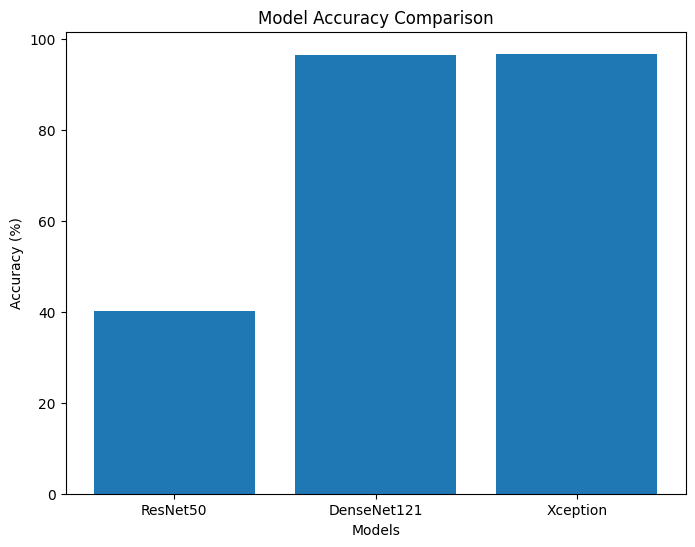

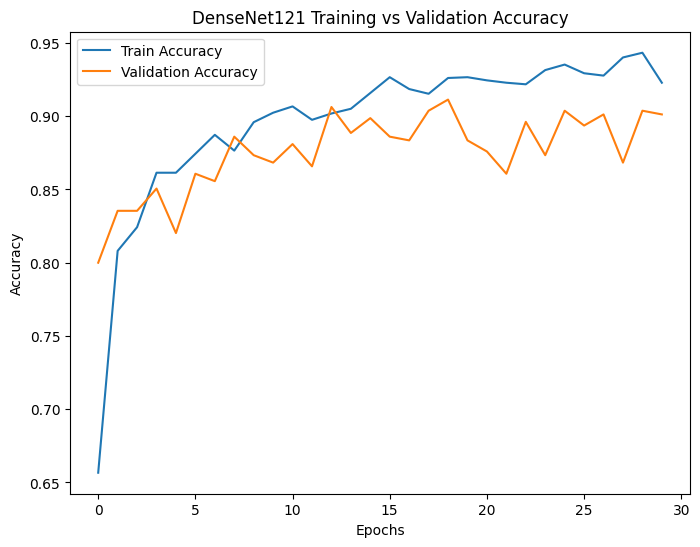

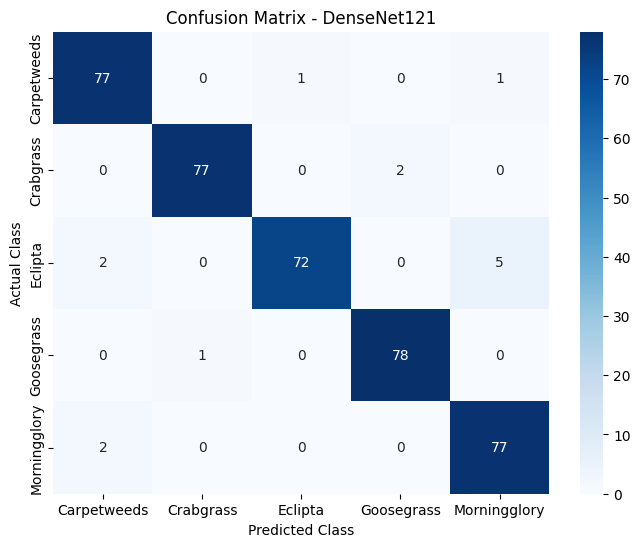


CLASSIFICATION REPORT - DenseNet121

              precision    recall  f1-score   support

 Carpetweeds       0.95      0.97      0.96        79
   Crabgrass       0.99      0.97      0.98        79
     Eclipta       0.99      0.91      0.95        79
  Goosegrass       0.97      0.99      0.98        79
Morningglory       0.93      0.97      0.95        79

    accuracy                           0.96       395
   macro avg       0.97      0.96      0.96       395
weighted avg       0.97      0.96      0.96       395


Best Model Selected → DenseNet121
Used for Final Weed Detection


In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Predicting ResNet50...")
resnet_pred = resnet_model.predict(val_data)
resnet_pred_classes = np.argmax(resnet_pred, axis=1)

print("Predicting DenseNet121...")
dense_pred = dense_model.predict(val_data)
dense_pred_classes = np.argmax(dense_pred, axis=1)

print("Predicting Xception...")
xception_pred = xception_model.predict(val_data)
xception_pred_classes = np.argmax(xception_pred, axis=1)

true_classes = val_data.classes

class_names = list(val_data.class_indices.keys())

def get_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    pre = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    return [
        round(acc * 100, 2),
        round(pre * 100, 2),
        round(rec * 100, 2),
        round(f1 * 100, 2)
    ]


results = pd.DataFrame({
    "Model": [
        "ResNet50",
        "DenseNet121",
        "Xception"
    ],
    "Accuracy (%)": [
        get_metrics(true_classes, resnet_pred_classes)[0],
        get_metrics(true_classes, dense_pred_classes)[0],
        get_metrics(true_classes, xception_pred_classes)[0]
    ],
    "Precision (%)": [
        get_metrics(true_classes, resnet_pred_classes)[1],
        get_metrics(true_classes, dense_pred_classes)[1],
        get_metrics(true_classes, xception_pred_classes)[1]
    ],
    "Recall (%)": [
        get_metrics(true_classes, resnet_pred_classes)[2],
        get_metrics(true_classes, dense_pred_classes)[2],
        get_metrics(true_classes, xception_pred_classes)[2]
    ],
    "F1 Score (%)": [
        get_metrics(true_classes, resnet_pred_classes)[3],
        get_metrics(true_classes, dense_pred_classes)[3],
        get_metrics(true_classes, xception_pred_classes)[3]
    ]
})

print("\n===================================================")
print("MODEL COMPARISON TABLE")
print("===================================================\n")
print(results)



plt.figure(figsize=(8,6))

plt.bar(
    results["Model"],
    results["Accuracy (%)"]
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.show()



plt.figure(figsize=(8,6))

plt.plot(history_frozen.history['accuracy'], label='Train Accuracy')
plt.plot(history_frozen.history['val_accuracy'], label='Validation Accuracy')

plt.title("DenseNet121 Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

cm = confusion_matrix(true_classes, dense_pred_classes)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - DenseNet121")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

print("\n===================================================")
print("CLASSIFICATION REPORT - DenseNet121")
print("===================================================\n")

print(classification_report(
    true_classes,
    dense_pred_classes,
    target_names=class_names
))


print("\nBest Model Selected → DenseNet121")
print("Used for Final Weed Detection")

Best Model Selected →xception_model
Model saved successfully!


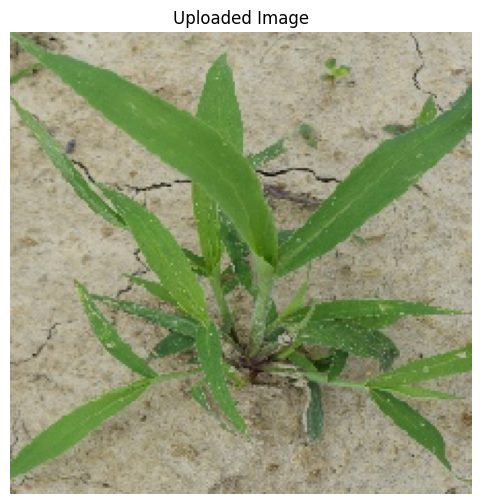

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step

🌱 WEED DETECTED
Predicted Weed Type: Crabgrass
Confidence Score: 99.94 %



In [81]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image


model = xception_model

print("Best Model Selected →xception_model")

model.save("weed_detection_model.h5")

print("Model saved successfully!")

classes = [
    'Carpetweeds',
    'Crabgrass',
    'Eclipta',
    'Goosegrass',
    'Morningglory'
]


def detect_weed(img_path):

    IMG_SIZE = 224
    threshold = 0.70   # 70% confidence threshold

    img = image.load_img(
        img_path,
        target_size=(IMG_SIZE, IMG_SIZE)
    )

    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Uploaded Image")
    plt.show()


    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)

    confidence = np.max(prediction)
    class_index = np.argmax(prediction)
    predicted_class = classes[class_index]


    print("\n===================================")

    if confidence > threshold:
        print("🌱 WEED DETECTED")
        print("Predicted Weed Type:", predicted_class)
        print("Confidence Score:",
              round(confidence * 100, 2), "%")
    else:
        print("❌ No Weed Detected")
        print("Confidence Score:",
              round(confidence * 100, 2), "%")

    print("===================================\n")


detect_weed(r"/content/drive/MyDrive/cotton_weed/Crabgrass/Crabgrass_10.jpg")